# 1. Raw Data Processing



* 1.1 The following code extracts 4 random 30-second segment from each raw audio file and saves it as a processed WAV clip, organized by genre.

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Configuration
GENRES = ["bebop", "cooljazz", "swing", "bossanova"]
BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/audio_clips'
SEGMENT_DURATION = 30
CLIPS_PER_SONG = 4
SAMPLE_RATE = 22050
np.random.seed(42)

def get_random_nonoverlapping_starts(total_duration, clip_duration, num_clips, max_attempts=1000):
    """
    Pick truly random start times that don't overlap.
    Each clip is clip_duration seconds long, and no two clips can share any time.
    """
    for _ in range(max_attempts):
        # Pick random start times anywhere in the valid range
        max_start = total_duration - clip_duration
        starts = np.random.uniform(0, max_start, size=num_clips)
        starts = np.sort(starts)

        # Check for overlaps: each start must be at least clip_duration apart
        no_overlap = True
        for i in range(1, len(starts)):
            if starts[i] - starts[i-1] < clip_duration:
                no_overlap = False
                break

        if no_overlap:
            return starts

    # Fallback: evenly spaced if random attempts fail (shouldn't happen for 4 clips)
    print("     (Falling back to evenly spaced clips)")
    return np.linspace(0, total_duration - clip_duration, num_clips)

print("=" * 50)
print("STEP 1: Extracting 30-second clips (RANDOM starts)")
print("=" * 50)

summary = {}

for genre in GENRES:
    print(f"\n{'='*40}")
    print(f"Processing: {genre.upper()}")
    print(f"{'='*40}")

    INPUT_DIR = os.path.join(BASE_DIR, f'raw_{genre}')
    OUTPUT_DIR = os.path.join(BASE_DIR, f'processed_{genre}_30s')

    if not os.path.exists(INPUT_DIR):
        print(f"  ERROR: {INPUT_DIR} not found. Skipping...")
        summary[genre] = 0
        continue

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    clip_counter = 1

    for filename in sorted(os.listdir(INPUT_DIR)):
        if filename.endswith(('.mp3', '.wav', '.m4a', '.flac')):
            file_path = os.path.join(INPUT_DIR, filename)
            print(f"  -> Processing: {filename}")

            try:
                audio_data, sr = librosa.load(file_path, sr=SAMPLE_RATE)
                total_duration = len(audio_data) / sr

                # Need at least clip_duration * num_clips seconds
                min_duration = SEGMENT_DURATION * CLIPS_PER_SONG
                if total_duration < min_duration:
                    print(f"     WARNING: Song is {total_duration:.1f}s, need {min_duration}s for {CLIPS_PER_SONG} non-overlapping clips.")
                    # Try to get as many as possible
                    possible_clips = int(total_duration // SEGMENT_DURATION)
                    if possible_clips == 0:
                        print(f"     SKIPPED: Too short for even one clip.")
                        continue
                    clips_to_extract = possible_clips
                else:
                    clips_to_extract = CLIPS_PER_SONG

                # Get random non-overlapping start times
                starts = get_random_nonoverlapping_starts(
                    total_duration, SEGMENT_DURATION, clips_to_extract
                )

                for start_time in starts:
                    start_sample = int(start_time * sr)
                    end_sample = start_sample + (SEGMENT_DURATION * sr)
                    audio_slice = audio_data[start_sample:end_sample]

                    output_filename = f"{genre}_{clip_counter:03d}.wav"
                    output_filepath = os.path.join(OUTPUT_DIR, output_filename)
                    sf.write(output_filepath, audio_slice, sr)

                    print(f"     Saved: {output_filename} (start: {start_time:.1f}s)")
                    clip_counter += 1

            except Exception as e:
                print(f"     ERROR: {e}")

    total_clips = clip_counter - 1
    summary[genre] = total_clips
    print(f"  Finished {genre}: {total_clips} clips created")

print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
for genre, count in summary.items():
    status = "OK" if count >= 100 else "LOW"
    print(f"  {genre:<12}: {count:>3} clips  [{status}]")
print(f"  {'TOTAL':<12}: {sum(summary.values()):>3} clips")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
STEP 1: Extracting 30-second clips (RANDOM starts)

Processing: BEBOP
  -> Processing: raw_bebop_001.wav
     Saved: bebop_001.wav (start: 9.5s)
     Saved: bebop_002.wav (start: 49.4s)
     Saved: bebop_003.wav (start: 93.0s)
     Saved: bebop_004.wav (start: 128.8s)
  -> Processing: raw_bebop_002.wav
     Saved: bebop_005.wav (start: 20.9s)
     Saved: bebop_006.wav (start: 58.9s)
     Saved: bebop_007.wav (start: 105.1s)
     Saved: bebop_008.wav (start: 142.6s)
  -> Processing: raw_bebop_003.wav
     Saved: bebop_009.wav (start: 54.1s)
     Saved: bebop_010.wav (start: 86.5s)
     Saved: bebop_011.wav (start: 121.6s)
     Saved: bebop_012.wav (start: 163.5s)
  -> Processing: raw_bebop_004.wav
     Saved: bebop_013.wav (start: 6.8s)
     Saved: bebop_014.wav (start: 42.0s)
     Saved: bebop_015.wav (start: 87.3s)
     Saved: bebop_016.wav (start: 134.7s)
 

* 1.2 The following code executes the conversion of 30-second audio clips into high-resolution Mel-spectrogram images, automatically organizing them into genre-specific folders.

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Directories
AUDIO_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/audio_clips'
IMAGE_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_30s'

# Spectrogram parameters
SAMPLE_RATE = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

print("=" * 50)
print("STEP 2: Generating Mel Spectrogram Images")
print("=" * 50)

for genre in GENRES:
    print(f"\n  Processing: {genre.upper()}")

    INPUT_DIR = os.path.join(AUDIO_BASE_DIR, f'processed_{genre}_30s')
    OUTPUT_DIR = os.path.join(IMAGE_BASE_DIR, genre)

    if not os.path.exists(INPUT_DIR):
        print(f"    WARNING: {INPUT_DIR} not found. Skipping...")
        continue

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    count = 0

    for filename in sorted(os.listdir(INPUT_DIR)):
        if filename.endswith('.wav'):
            file_path = os.path.join(INPUT_DIR, filename)

            try:
                audio_data, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                # Generate mel spectrogram
                mel_spec = librosa.feature.melspectrogram(
                    y=audio_data, sr=sr,
                    n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
                )
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

                # Save at 300x300 so ResNet resize to 224x224 preserves detail
                fig, ax = plt.subplots(figsize=(3, 3), dpi=100)
                librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP_LENGTH, ax=ax)
                ax.axis('off')

                base_name = os.path.splitext(filename)[0]
                output_filepath = os.path.join(OUTPUT_DIR, f"{base_name}.png")
                plt.savefig(output_filepath, bbox_inches='tight', pad_inches=0)
                plt.close(fig)
                count += 1

            except Exception as e:
                print(f"    ERROR on {filename}: {e}")

    print(f"    -> {count} spectrogram images saved")

print("\nAll spectrogram images generated!")

STEP 2: Generating Mel Spectrogram Images

  Processing: BEBOP
    -> 100 spectrogram images saved

  Processing: COOLJAZZ
    -> 100 spectrogram images saved

  Processing: SWING
    -> 100 spectrogram images saved

  Processing: BOSSANOVA
    -> 100 spectrogram images saved

All spectrogram images generated!


* 1.3 The following code do a sanity check: count the images per genre and show you a sample spectrogram from each so we can visually confirm they look right.

Dataset Verification:
------------------------------
  bebop       : 100 images
  cooljazz    : 100 images
  swing       : 100 images
  bossanova   : 100 images


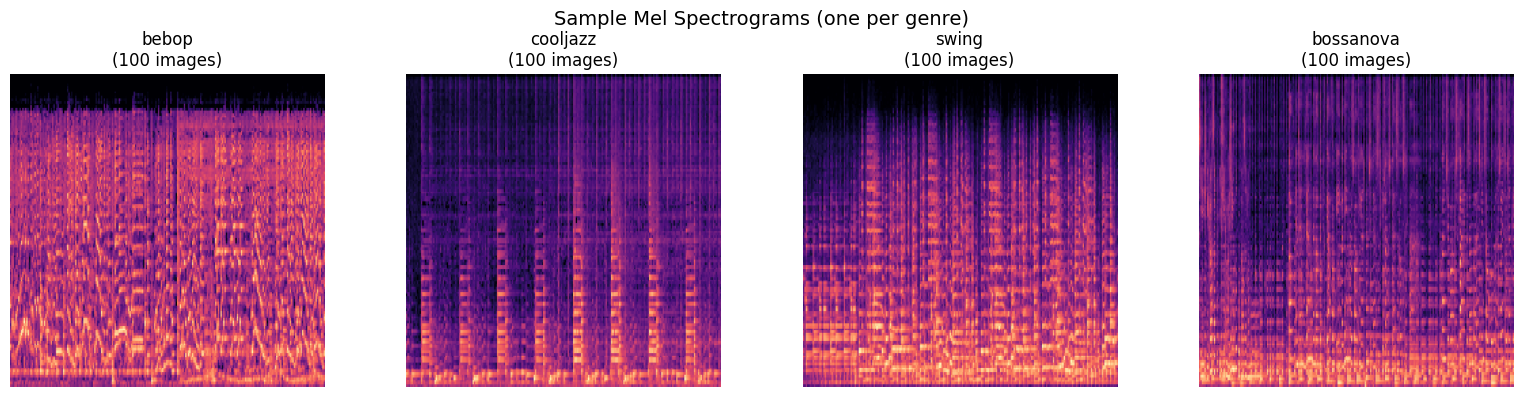

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_30s'

print("Dataset Verification:")
print("-" * 30)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, genre in enumerate(GENRES):
    genre_dir = os.path.join(IMAGE_BASE_DIR, genre)
    if os.path.exists(genre_dir):
        files = [f for f in os.listdir(genre_dir) if f.endswith('.png')]
        print(f"  {genre:<12}: {len(files)} images")

        # Show a sample image
        if files:
            sample_img = Image.open(os.path.join(genre_dir, sorted(files)[0]))
            axes[idx].imshow(sample_img)
            axes[idx].set_title(f"{genre}\n({len(files)} images)")
            axes[idx].axis('off')
    else:
        print(f"  {genre:<12}: MISSING")
        axes[idx].set_title(f"{genre}\nMISSING")
        axes[idx].axis('off')

plt.suptitle("Sample Mel Spectrograms (one per genre)", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Dataset Splitting and DataLoader Setup

This cell sets up the PyTorch data pipeline that will feed images to our model. It does three key things:

* Separate transforms: training images get data augmentation (random horizontal flips and random erasing to simulate masking), while validation images are kept clean. This helps the model generalize better with only 400 images.
* Stratified 80/20 split: instead of a purely random split, stratification guarantees each genre has exactly the same proportion in both the training and validation sets (80 train / 20 val per genre).
* DataLoaders: these act like conveyor belts that feed batches of 32 images at a time to the GPU during training.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter
from PIL import Image
import numpy as np

# 1. Define SEPARATE transforms for training vs validation
# Training: add augmentation to help generalize on a small dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

# Validation: just resize and normalize, no augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Setting up PyTorch Data Pipeline...")

# 2. Load full dataset with val_transform first (we'll apply train_transform separately)
DATA_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_30s'
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

print(f"Discovered Classes: {full_dataset.class_to_idx}")
print(f"Total images: {len(full_dataset)}")

# 3. Stratified split: ensures equal genre representation in train/val
labels = [label for _, label in full_dataset.samples]
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = next(splitter.split(np.zeros(len(labels)), labels))

# 4. Create a custom dataset that applies train_transform to training images
class TrainSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        path, label = self.dataset.samples[original_idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label

train_dataset = TrainSubset(full_dataset, train_indices, train_transform)
val_dataset = Subset(full_dataset, val_indices)

print(f"\n  Training set:   {len(train_dataset)} images (with augmentation)")
print(f"  Validation set: {len(val_dataset)} images (no augmentation)")

# 5. Verify stratification
class_names = full_dataset.classes
train_labels = [labels[i] for i in train_indices]
val_labels = [labels[i] for i in val_indices]
print(f"\n  Train distribution: { {class_names[k]: v for k, v in sorted(Counter(train_labels).items())} }")
print(f"  Val distribution:   { {class_names[k]: v for k, v in sorted(Counter(val_labels).items())} }")

# 6. Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders ready! (batch_size={BATCH_SIZE})")

Setting up PyTorch Data Pipeline...
Discovered Classes: {'bebop': 0, 'bossanova': 1, 'cooljazz': 2, 'swing': 3}
Total images: 400

  Training set:   320 images (with augmentation)
  Validation set: 80 images (no augmentation)

  Train distribution: {'bebop': 80, 'bossanova': 80, 'cooljazz': 80, 'swing': 80}
  Val distribution:   {'bebop': 20, 'bossanova': 20, 'cooljazz': 20, 'swing': 20}

DataLoaders ready! (batch_size=32)


# 3. Model Setup: ResNet-18 Transfer Learning

This cell loads a pre-trained ResNet-18 model (trained on ImageNet) and replaces its final layer to output our 4 jazz genres. We also set up the loss function (CrossEntropyLoss), optimizer (Adam with weight decay), and a learning rate scheduler that automatically reduces the learning rate when validation loss stops improving.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device.type.upper()}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# 2. Load pre-trained ResNet-18
print("Loading pre-trained ResNet-18...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 3. Replace final layer for our 4 genres
num_ftrs = model.fc.in_features
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# 4. Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"\nResNet-18 configured for {num_classes} classes: {full_dataset.classes}")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

Using device: CUDA
  GPU: Tesla T4
Loading pre-trained ResNet-18...

ResNet-18 configured for 4 classes: ['bebop', 'bossanova', 'cooljazz', 'swing']
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


# 4. Training Loop

This following cell trains the ResNet-18 model on our 320 training spectrograms and evaluates it on the 80 validation images each epoch. It includes early stopping (patience=5), which automatically stops training if the validation loss hasn't improved for 5 consecutive epochs; this prevents overfitting. The learning rate scheduler also kicks in to reduce the learning rate when progress stalls. The best model weights are saved throughout training.

In [ ]:
import time
import copy

# Training configuration
EPOCHS = 25
EARLY_STOP_PATIENCE = 5
best_acc = 0.0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

# Metrics tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print(f"Starting training on {device.type.upper()} for up to {EPOCHS} epochs...")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE}")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_acc.item())
            print(f"  Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        else:
            val_losses.append(epoch_loss)
            val_accuracies.append(epoch_acc.item())

            # Step the scheduler based on validation loss
            scheduler.step(epoch_loss)

            # Check for improvement
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  *** New best! ***")
            else:
                epochs_no_improve += 1
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  (no improve: {epochs_no_improve}/{EARLY_STOP_PATIENCE})")

    # Early stopping check
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

# Wrap up
time_elapsed = time.time() - start_time
actual_epochs = len(train_losses)
print(f"\n{'='*50}")
print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Epochs trained: {actual_epochs}")
print(f"Best Validation Accuracy: {best_acc:.4f}")
print(f"{'='*50}")

# Restore best model weights
model.load_state_dict(best_model_wts)
print("Best model weights restored!")

Starting training on CUDA for up to 25 epochs...
Early stopping patience: 5

Epoch 1/25
------------------------------
  Train Loss: 1.1865 | Acc: 0.5750
  Val   Loss: 11.5746 | Acc: 0.2500  *** New best! ***

Epoch 2/25
------------------------------
  Train Loss: 0.5484 | Acc: 0.7750
  Val   Loss: 2.8621 | Acc: 0.5875  *** New best! ***

Epoch 3/25
------------------------------
  Train Loss: 0.3819 | Acc: 0.8625
  Val   Loss: 1.6232 | Acc: 0.6250  *** New best! ***

Epoch 4/25
------------------------------
  Train Loss: 0.2965 | Acc: 0.8844
  Val   Loss: 1.4258 | Acc: 0.6250  *** New best! ***

Epoch 5/25
------------------------------
  Train Loss: 0.2146 | Acc: 0.9156
  Val   Loss: 2.1935 | Acc: 0.6125  (no improve: 1/5)

Epoch 6/25
------------------------------
  Train Loss: 0.1979 | Acc: 0.9281
  Val   Loss: 1.2862 | Acc: 0.7375  *** New best! ***

Epoch 7/25
------------------------------
  Train Loss: 0.1484 | Acc: 0.9438
  Val   Loss: 0.4539 | Acc: 0.8250  *** New best! ***

# 5. Model Evaluation and Performance Visualization

* 5.1 **Training & Validation Curves** \
This cell plots the accuracy and loss curves across all training epochs. We're looking for two things: (1) both curves trending in the right direction (accuracy up, loss down), and (2) the gap between training and validation curves: a large gap indicates overfitting.

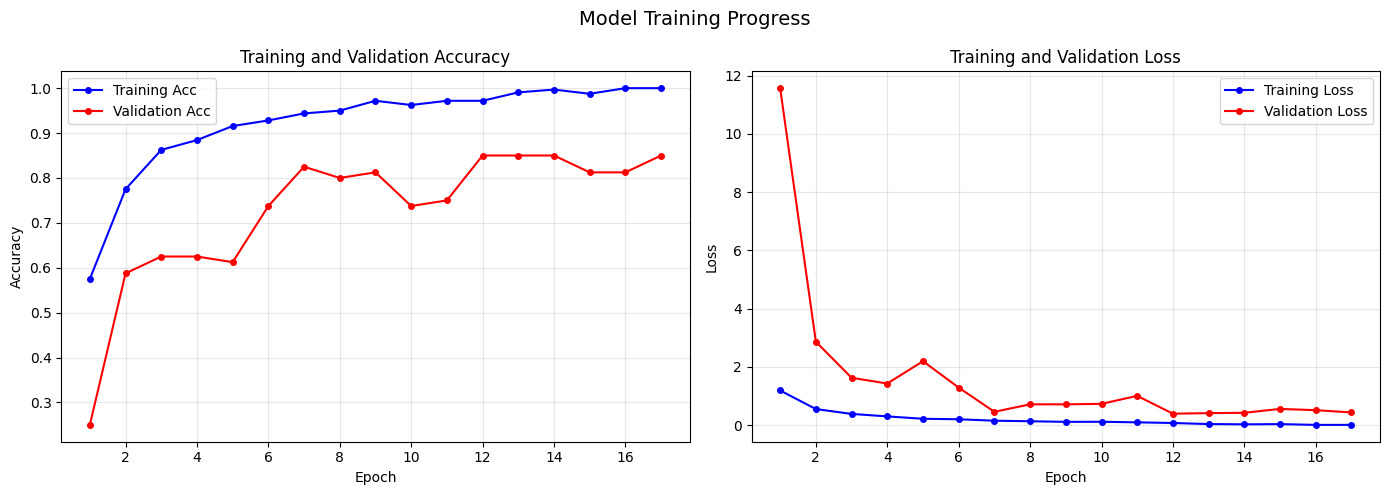

In [ ]:
import matplotlib.pyplot as plt

actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_range, train_accuracies, 'b-o', label='Training Acc', markersize=4)
ax1.plot(epochs_range, val_accuracies, 'r-o', label='Validation Acc', markersize=4)
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_range, train_losses, 'b-o', label='Training Loss', markersize=4)
ax2.plot(epochs_range, val_losses, 'r-o', label='Validation Loss', markersize=4)
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

* 5.2 **Confusion Matrix & Classification Report** \
This cell generates a confusion matrix showing how many images from each genre were classified correctly vs. misclassified, and a detailed classification report with precision, recall, and F1-score per genre.

Generating predictions for confusion matrix...


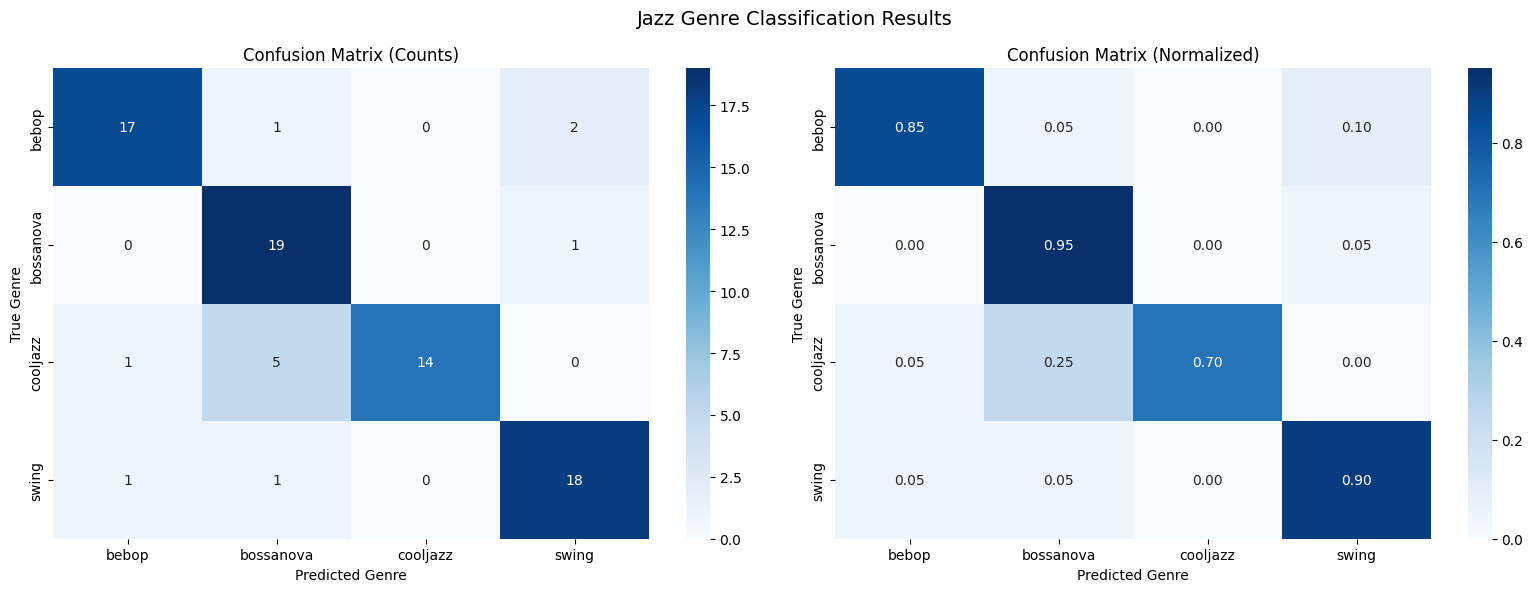


Detailed Classification Report:
              precision    recall  f1-score   support

       bebop       0.89      0.85      0.87        20
   bossanova       0.73      0.95      0.83        20
    cooljazz       1.00      0.70      0.82        20
       swing       0.86      0.90      0.88        20

    accuracy                           0.85        80
   macro avg       0.87      0.85      0.85        80
weighted avg       0.87      0.85      0.85        80



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Gather predictions on validation set
model.eval()
all_preds = []
all_labels = []

print("Generating predictions for confusion matrix...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = full_dataset.classes

# Raw counts confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Normalized confusion matrix (percentages per true class)
cm_norm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)), normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_ylabel('True Genre')
ax1.set_xlabel('Predicted Genre')

sns.heatmap(cm_norm_df, annot=True, fmt='.2f', cmap='Blues', ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)')
ax2.set_ylabel('True Genre')
ax2.set_xlabel('Predicted Genre')

plt.suptitle('Jazz Genre Classification Results', fontsize=14)
plt.tight_layout()
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                            target_names=class_names,
                            labels=range(len(class_names)),
                            zero_division=0))

* 5.3 **Save Trained Model** \
This cell saves the trained model weights and metadata to Google Drive so we don't have to retrain if the runtime disconnects.

In [ ]:
# Save model weights to Google Drive
SAVE_PATH = '/content/drive/MyDrive/DS340_Final_Project/resnet18_jazz_classifier.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': full_dataset.classes,
    'class_to_idx': full_dataset.class_to_idx,
    'best_val_acc': best_acc.item(),
    'epochs_trained': actual_epochs,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
}, SAVE_PATH)

print(f"Model saved to: {SAVE_PATH}")
print(f"  Best validation accuracy: {best_acc:.4f}")
print(f"  Epochs trained: {actual_epochs}")

Model saved to: /content/drive/MyDrive/DS340_Final_Project/resnet18_jazz_classifier.pth
  Best validation accuracy: 0.8500
  Epochs trained: 17


# 6. Experiment 1: Model Architecture Comparison

This experiment compares three model architectures on the same dataset to explore how network depth and complexity affect jazz subgenre classification. Setting A is a simple custom CNN (baseline), Setting B is ResNet-18 (already completed above with 85% accuracy), and Setting C is ResNet-50 (deeper network).

In [ ]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

GENRES = ["bebop", "cooljazz", "swing", "bossanova"]

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
DATA_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_30s'
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
labels = [label for _, label in full_dataset.samples]
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = next(splitter.split(np.zeros(len(labels)), labels))

class TrainSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        path, label = self.dataset.samples[original_idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label

train_dataset = TrainSubset(full_dataset, train_indices, train_transform)
val_dataset = Subset(full_dataset, val_indices)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device.type.upper()}")
print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print("Ready for experiments!")

Mounted at /content/drive
Device: CUDA
Classes: ['bebop', 'bossanova', 'cooljazz', 'swing']
Train: 320 | Val: 80
Ready for experiments!


* 6.1 This is a simple 3-layer convolutional network built from scratch with no pre-trained weights. It serves as a baseline to measure how much transfer learning (ResNet-18) helps compared to training a CNN from scratch.

In [ ]:
import torch
import torch.nn as nn
import time
import copy

# 1. Define the Custom CNN
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        # Conv Block 1: 3 input channels (RGB) -> 32 feature maps
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 224x224 -> 112x112
        )

        # Conv Block 2: 32 -> 64 feature maps
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 112x112 -> 56x56
        )

        # Conv Block 3: 64 -> 128 feature maps
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 56x56 -> 28x28
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.classifier(x)
        return x

# 2. Setup
custom_cnn = CustomCNN(num_classes=len(full_dataset.classes)).to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(custom_cnn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn, mode='min', factor=0.5, patience=3
)

# Count parameters to compare with ResNet-18
total_params = sum(p.numel() for p in custom_cnn.parameters())
print(f"Custom CNN created with {total_params:,} parameters")
print(f"(For reference, ResNet-18 has ~11.2 million parameters)")
print(f"\nArchitecture:\n{custom_cnn}")

Custom CNN created with 25,785,092 parameters
(For reference, ResNet-18 has ~11.2 million parameters)

Architecture:
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

* 6.1.1 Training Custom CNN

In [ ]:
# Training configuration
EPOCHS = 25
EARLY_STOP_PATIENCE = 5
best_acc_cnn = 0.0
best_val_loss_cnn = float('inf')
best_model_wts_cnn = copy.deepcopy(custom_cnn.state_dict())
epochs_no_improve_cnn = 0

cnn_train_losses, cnn_val_losses = [], []
cnn_train_accs, cnn_val_accs = [], []

print(f"Training Custom CNN on {device.type.upper()}...")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            custom_cnn.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            custom_cnn.eval()
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_cnn.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = custom_cnn(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion_cnn(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_cnn.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            cnn_train_losses.append(epoch_loss)
            cnn_train_accs.append(epoch_acc.item())
            print(f"  Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        else:
            cnn_val_losses.append(epoch_loss)
            cnn_val_accs.append(epoch_acc.item())
            scheduler_cnn.step(epoch_loss)

            if epoch_loss < best_val_loss_cnn:
                best_val_loss_cnn = epoch_loss
                best_acc_cnn = epoch_acc
                best_model_wts_cnn = copy.deepcopy(custom_cnn.state_dict())
                epochs_no_improve_cnn = 0
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  *** New best! ***")
            else:
                epochs_no_improve_cnn += 1
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  (no improve: {epochs_no_improve_cnn}/{EARLY_STOP_PATIENCE})")

    if epochs_no_improve_cnn >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

time_elapsed = time.time() - start_time
cnn_epochs = len(cnn_train_losses)
print(f"\n{'='*50}")
print(f"Custom CNN Training Complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Epochs trained: {cnn_epochs}")
print(f"Best Validation Accuracy: {best_acc_cnn:.4f}")
print(f"{'='*50}")

custom_cnn.load_state_dict(best_model_wts_cnn)
print("Best model weights restored!")

Training Custom CNN on CUDA...

Epoch 1/25
------------------------------
  Train Loss: 36.3467 | Acc: 0.2812
  Val   Loss: 8.4039 | Acc: 0.3250  *** New best! ***

Epoch 2/25
------------------------------
  Train Loss: 6.6021 | Acc: 0.4219
  Val   Loss: 2.5607 | Acc: 0.4250  *** New best! ***

Epoch 3/25
------------------------------
  Train Loss: 2.1982 | Acc: 0.3906
  Val   Loss: 1.4299 | Acc: 0.3875  *** New best! ***

Epoch 4/25
------------------------------
  Train Loss: 1.2044 | Acc: 0.4062
  Val   Loss: 1.2482 | Acc: 0.3875  *** New best! ***

Epoch 5/25
------------------------------
  Train Loss: 1.1914 | Acc: 0.3750
  Val   Loss: 1.2593 | Acc: 0.3875  (no improve: 1/5)

Epoch 6/25
------------------------------
  Train Loss: 1.1507 | Acc: 0.4219
  Val   Loss: 1.2726 | Acc: 0.4250  (no improve: 2/5)

Epoch 7/25
------------------------------
  Train Loss: 1.1473 | Acc: 0.4156
  Val   Loss: 1.3013 | Acc: 0.4125  (no improve: 3/5)

Epoch 8/25
------------------------------
 

* 6.2 This part tests whether a deeper netweok (50 layers vs 18) can capture more nuanced differences between each jazz subgenres, or whether it overfits on our dataset.


In [ ]:
from torchvision import models

# 1. Load pre-trained ResNet-50
print("Loading pre-trained ResNet-50...")
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Replace final layer for our 4 genres
num_ftrs_50 = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs_50, len(full_dataset.classes))
resnet50 = resnet50.to(device)

# 3. Optimizer and scheduler
criterion_50 = nn.CrossEntropyLoss()
optimizer_50 = torch.optim.Adam(resnet50.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_50 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_50, mode='min', factor=0.5, patience=3
)

total_params_50 = sum(p.numel() for p in resnet50.parameters())
print(f"ResNet-50: {total_params_50:,} parameters")
print(f"(ResNet-18 had ~11.2M, Custom CNN had ~25.7M)")

Loading pre-trained ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.4MB/s]


ResNet-50: 23,516,228 parameters
(ResNet-18 had ~11.2M, Custom CNN had ~25.7M)


* 6.2.1 Training ResNet-50

In [ ]:
# Training configuration
EPOCHS = 25
EARLY_STOP_PATIENCE = 5
best_acc_50 = 0.0
best_val_loss_50 = float('inf')
best_model_wts_50 = copy.deepcopy(resnet50.state_dict())
epochs_no_improve_50 = 0

r50_train_losses, r50_val_losses = [], []
r50_train_accs, r50_val_accs = [], []

print(f"Training ResNet-50 on {device.type.upper()}...")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            resnet50.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            resnet50.eval()
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_50.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = resnet50(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion_50(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_50.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            r50_train_losses.append(epoch_loss)
            r50_train_accs.append(epoch_acc.item())
            print(f"  Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        else:
            r50_val_losses.append(epoch_loss)
            r50_val_accs.append(epoch_acc.item())
            scheduler_50.step(epoch_loss)

            if epoch_loss < best_val_loss_50:
                best_val_loss_50 = epoch_loss
                best_acc_50 = epoch_acc
                best_model_wts_50 = copy.deepcopy(resnet50.state_dict())
                epochs_no_improve_50 = 0
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  *** New best! ***")
            else:
                epochs_no_improve_50 += 1
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  (no improve: {epochs_no_improve_50}/{EARLY_STOP_PATIENCE})")

    if epochs_no_improve_50 >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

time_elapsed = time.time() - start_time
r50_epochs = len(r50_train_losses)
print(f"\n{'='*50}")
print(f"ResNet-50 Training Complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Epochs trained: {r50_epochs}")
print(f"Best Validation Accuracy: {best_acc_50:.4f}")
print(f"{'='*50}")

resnet50.load_state_dict(best_model_wts_50)
print("Best model weights restored!")

Training ResNet-50 on CUDA...

Epoch 1/25
------------------------------
  Train Loss: 1.0435 | Acc: 0.6031
  Val   Loss: 1.9019 | Acc: 0.5750  *** New best! ***

Epoch 2/25
------------------------------
  Train Loss: 0.6387 | Acc: 0.7875
  Val   Loss: 1.7894 | Acc: 0.6125  *** New best! ***

Epoch 3/25
------------------------------
  Train Loss: 0.4390 | Acc: 0.8750
  Val   Loss: 1.0681 | Acc: 0.6875  *** New best! ***

Epoch 4/25
------------------------------
  Train Loss: 0.2837 | Acc: 0.9062
  Val   Loss: 1.4353 | Acc: 0.7250  (no improve: 1/5)

Epoch 5/25
------------------------------
  Train Loss: 0.1671 | Acc: 0.9500
  Val   Loss: 1.2265 | Acc: 0.6750  (no improve: 2/5)

Epoch 6/25
------------------------------
  Train Loss: 0.0900 | Acc: 0.9719
  Val   Loss: 0.8148 | Acc: 0.7250  *** New best! ***

Epoch 7/25
------------------------------
  Train Loss: 0.1078 | Acc: 0.9594
  Val   Loss: 0.9762 | Acc: 0.7375  (no improve: 1/5)

Epoch 8/25
------------------------------
  T

* 6.3 Experiment 1 results comparison: side-by-side comparison of all three model architectures.

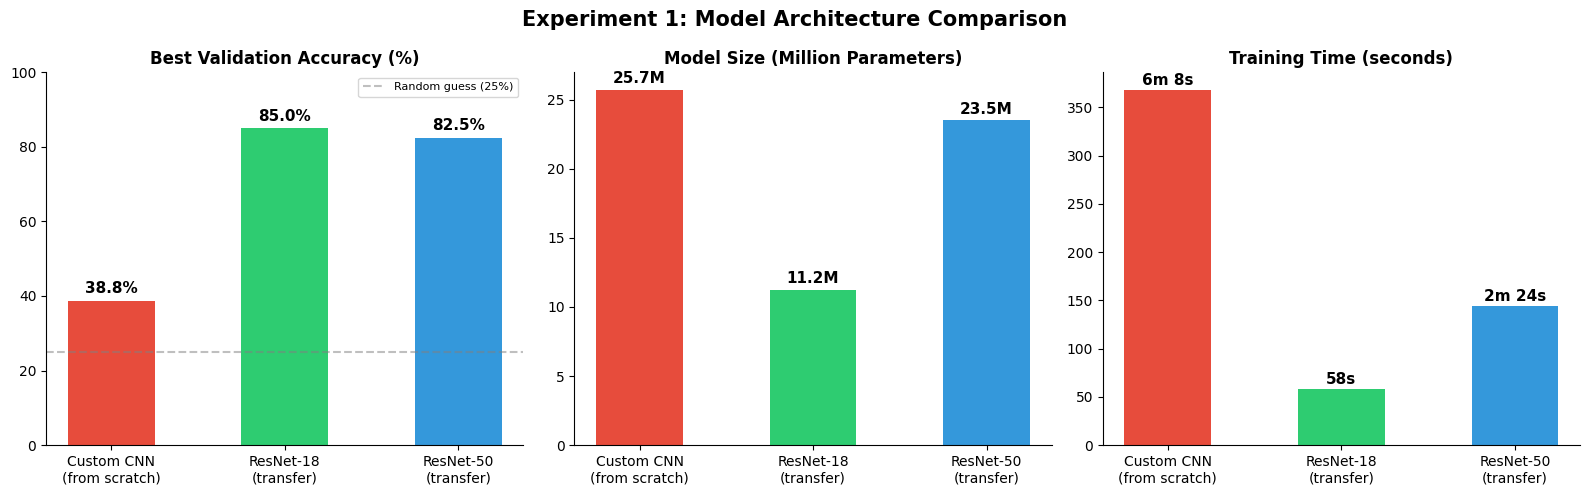

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models_names = ['Custom CNN\n(from scratch)', 'ResNet-18\n(transfer)', 'ResNet-50\n(transfer)']
accuracies = [38.75, 85.00, 82.50]
params = [25.7, 11.2, 23.5]
train_times = [368, 58, 144]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']

# 1. Accuracy
bars1 = axes[0].bar(models_names, accuracies, color=colors, width=0.5)
axes[0].set_title('Best Validation Accuracy (%)', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random guess (25%)')
axes[0].legend(fontsize=8)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 2. Parameters
bars2 = axes[1].bar(models_names, params, color=colors, width=0.5)
axes[1].set_title('Model Size (Million Parameters)', fontweight='bold')
for bar, p in zip(bars2, params):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{p}M', ha='center', fontsize=11, fontweight='bold')

# 3. Training time
bars3 = axes[2].bar(models_names, train_times, color=colors, width=0.5)
axes[2].set_title('Training Time (seconds)', fontweight='bold')
for bar, t in zip(bars3, train_times):
    mins = t // 60
    secs = t % 60
    label = f'{mins}m {secs}s' if mins > 0 else f'{secs}s'
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 label, ha='center', fontsize=11, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Experiment 1: Model Architecture Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Experiment 2: Audio Feature Representation Comparison

This experiment tests which visual representation of audio captures the nuances of jazz styles most effectively. We use the same model (ResNet-18) and the same 400 audio clips, but convert them into three different image types. Setting A is mel spectrograms (already completed above with 85% accuracy), Setting B is MFCCs, and Setting C is chromagrams.


* 7.1 Generate MFCC and chromagram images: MFCCs focus on timbral textures (the "color" of sound), while chromagrams highlight harmonic and chordal patterns (which notes are being played). These capture different musical properties than mel spectrograms, which show overall energy across frequency bands.

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

AUDIO_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/audio_clips'
MFCC_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_mfcc'
CHROMA_BASE_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_chroma'

SAMPLE_RATE = 22050
N_MFCC = 40
HOP_LENGTH = 512

print("=" * 50)
print("Generating MFCC and Chromagram images")
print("=" * 50)

for genre in GENRES:
    print(f"\n  Processing: {genre.upper()}")

    INPUT_DIR = os.path.join(AUDIO_BASE_DIR, f'processed_{genre}_30s')
    MFCC_DIR = os.path.join(MFCC_BASE_DIR, genre)
    CHROMA_DIR = os.path.join(CHROMA_BASE_DIR, genre)

    if not os.path.exists(INPUT_DIR):
        print(f"    WARNING: {INPUT_DIR} not found. Skipping...")
        continue

    os.makedirs(MFCC_DIR, exist_ok=True)
    os.makedirs(CHROMA_DIR, exist_ok=True)
    count = 0

    for filename in sorted(os.listdir(INPUT_DIR)):
        if filename.endswith('.wav'):
            file_path = os.path.join(INPUT_DIR, filename)
            base_name = os.path.splitext(filename)[0]

            try:
                audio_data, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                # --- MFCC ---
                mfcc = librosa.feature.mfcc(
                    y=audio_data, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH
                )
                fig, ax = plt.subplots(figsize=(3, 3), dpi=100)
                librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH, ax=ax)
                ax.axis('off')
                plt.savefig(os.path.join(MFCC_DIR, f"{base_name}.png"),
                            bbox_inches='tight', pad_inches=0)
                plt.close(fig)

                # --- Chromagram ---
                chroma = librosa.feature.chroma_stft(
                    y=audio_data, sr=sr, hop_length=HOP_LENGTH
                )
                fig, ax = plt.subplots(figsize=(3, 3), dpi=100)
                librosa.display.specshow(chroma, sr=sr, hop_length=HOP_LENGTH, ax=ax)
                ax.axis('off')
                plt.savefig(os.path.join(CHROMA_DIR, f"{base_name}.png"),
                            bbox_inches='tight', pad_inches=0)
                plt.close(fig)

                count += 1

            except Exception as e:
                print(f"    ERROR on {filename}: {e}")

    print(f"    -> {count} MFCC + {count} Chromagram images saved")

print("\nAll feature images generated!")

Generating MFCC and Chromagram images

  Processing: BEBOP
    -> 100 MFCC + 100 Chromagram images saved

  Processing: COOLJAZZ
    -> 100 MFCC + 100 Chromagram images saved

  Processing: SWING
    -> 100 MFCC + 100 Chromagram images saved

  Processing: BOSSANOVA
    -> 100 MFCC + 100 Chromagram images saved

All feature images generated!


* 7.2 Setting B: MFCC (Training ResNet-18): Training a fresh ResNet-18 on MFCC images to see if timbral features outperform mel spectrograms for jazz classification.

In [ ]:
from torchvision import models

# 1. Load MFCC dataset
MFCC_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_mfcc'
mfcc_dataset = datasets.ImageFolder(root=MFCC_DIR, transform=val_transform)

# 2. Stratified split (same indices as before for fair comparison)
mfcc_train = TrainSubset(mfcc_dataset, train_indices, train_transform)
mfcc_val = Subset(mfcc_dataset, val_indices)
mfcc_train_loader = DataLoader(mfcc_train, batch_size=32, shuffle=True)
mfcc_val_loader = DataLoader(mfcc_val, batch_size=32, shuffle=False)

print(f"MFCC Dataset: {len(mfcc_train)} train / {len(mfcc_val)} val")

# 3. Fresh ResNet-18
mfcc_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
mfcc_model.fc = nn.Linear(mfcc_model.fc.in_features, len(mfcc_dataset.classes))
mfcc_model = mfcc_model.to(device)

criterion_mfcc = nn.CrossEntropyLoss()
optimizer_mfcc = torch.optim.Adam(mfcc_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_mfcc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mfcc, mode='min', factor=0.5, patience=3
)

# 4. Train
EPOCHS = 25
EARLY_STOP_PATIENCE = 5
best_acc_mfcc = 0.0
best_val_loss_mfcc = float('inf')
best_model_wts_mfcc = copy.deepcopy(mfcc_model.state_dict())
epochs_no_improve_mfcc = 0

mfcc_train_losses, mfcc_val_losses = [], []
mfcc_train_accs, mfcc_val_accs = [], []

print(f"Training ResNet-18 on MFCCs...")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            mfcc_model.train()
            dataloader = mfcc_train_loader
            dataset_size = len(mfcc_train)
        else:
            mfcc_model.eval()
            dataloader = mfcc_val_loader
            dataset_size = len(mfcc_val)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_mfcc.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = mfcc_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion_mfcc(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_mfcc.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            mfcc_train_losses.append(epoch_loss)
            mfcc_train_accs.append(epoch_acc.item())
            print(f"  Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        else:
            mfcc_val_losses.append(epoch_loss)
            mfcc_val_accs.append(epoch_acc.item())
            scheduler_mfcc.step(epoch_loss)

            if epoch_loss < best_val_loss_mfcc:
                best_val_loss_mfcc = epoch_loss
                best_acc_mfcc = epoch_acc
                best_model_wts_mfcc = copy.deepcopy(mfcc_model.state_dict())
                epochs_no_improve_mfcc = 0
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  *** New best! ***")
            else:
                epochs_no_improve_mfcc += 1
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  (no improve: {epochs_no_improve_mfcc}/{EARLY_STOP_PATIENCE})")

    if epochs_no_improve_mfcc >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

time_elapsed = time.time() - start_time
mfcc_epochs = len(mfcc_train_losses)
print(f"\n{'='*50}")
print(f"MFCC Training Complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Epochs trained: {mfcc_epochs}")
print(f"Best Validation Accuracy: {best_acc_mfcc:.4f}")
print(f"{'='*50}")

mfcc_model.load_state_dict(best_model_wts_mfcc)
print("Best model weights restored!")

MFCC Dataset: 320 train / 80 val
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.8MB/s]


Training ResNet-18 on MFCCs...

Epoch 1/25
------------------------------
  Train Loss: 1.3891 | Acc: 0.5031
  Val   Loss: 10.7207 | Acc: 0.3250  *** New best! ***

Epoch 2/25
------------------------------
  Train Loss: 0.8449 | Acc: 0.6719
  Val   Loss: 4.0255 | Acc: 0.3750  *** New best! ***

Epoch 3/25
------------------------------
  Train Loss: 0.5907 | Acc: 0.7844
  Val   Loss: 0.9669 | Acc: 0.6500  *** New best! ***

Epoch 4/25
------------------------------
  Train Loss: 0.6579 | Acc: 0.7625
  Val   Loss: 2.0468 | Acc: 0.4625  (no improve: 1/5)

Epoch 5/25
------------------------------
  Train Loss: 0.6639 | Acc: 0.7563
  Val   Loss: 1.1240 | Acc: 0.6875  (no improve: 2/5)

Epoch 6/25
------------------------------
  Train Loss: 0.5161 | Acc: 0.8094
  Val   Loss: 2.0842 | Acc: 0.4000  (no improve: 3/5)

Epoch 7/25
------------------------------
  Train Loss: 0.5385 | Acc: 0.8313
  Val   Loss: 1.0315 | Acc: 0.5625  (no improve: 4/5)

Epoch 8/25
------------------------------
 

* 7.3 Setting C: Chromagram (Training ResNet-18): Training a fresh ResNet-18 on chromagram images to see if harmonic and chordal patterns are useful for jazz classification.

In [ ]:
# 1. Load Chromagram dataset
CHROMA_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_chroma'
chroma_dataset = datasets.ImageFolder(root=CHROMA_DIR, transform=val_transform)

# 2. Same stratified split
chroma_train = TrainSubset(chroma_dataset, train_indices, train_transform)
chroma_val = Subset(chroma_dataset, val_indices)
chroma_train_loader = DataLoader(chroma_train, batch_size=32, shuffle=True)
chroma_val_loader = DataLoader(chroma_val, batch_size=32, shuffle=False)

print(f"Chromagram Dataset: {len(chroma_train)} train / {len(chroma_val)} val")

# 3. Fresh ResNet-18
chroma_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
chroma_model.fc = nn.Linear(chroma_model.fc.in_features, len(chroma_dataset.classes))
chroma_model = chroma_model.to(device)

criterion_chroma = nn.CrossEntropyLoss()
optimizer_chroma = torch.optim.Adam(chroma_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_chroma = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_chroma, mode='min', factor=0.5, patience=3
)

# 4. Train
EPOCHS = 25
EARLY_STOP_PATIENCE = 5
best_acc_chroma = 0.0
best_val_loss_chroma = float('inf')
best_model_wts_chroma = copy.deepcopy(chroma_model.state_dict())
epochs_no_improve_chroma = 0

chroma_train_losses, chroma_val_losses = [], []
chroma_train_accs, chroma_val_accs = [], []

print(f"Training ResNet-18 on Chromagrams...")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            chroma_model.train()
            dataloader = chroma_train_loader
            dataset_size = len(chroma_train)
        else:
            chroma_model.eval()
            dataloader = chroma_val_loader
            dataset_size = len(chroma_val)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_chroma.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = chroma_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion_chroma(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_chroma.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            chroma_train_losses.append(epoch_loss)
            chroma_train_accs.append(epoch_acc.item())
            print(f"  Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        else:
            chroma_val_losses.append(epoch_loss)
            chroma_val_accs.append(epoch_acc.item())
            scheduler_chroma.step(epoch_loss)

            if epoch_loss < best_val_loss_chroma:
                best_val_loss_chroma = epoch_loss
                best_acc_chroma = epoch_acc
                best_model_wts_chroma = copy.deepcopy(chroma_model.state_dict())
                epochs_no_improve_chroma = 0
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  *** New best! ***")
            else:
                epochs_no_improve_chroma += 1
                print(f"  Val   Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}  (no improve: {epochs_no_improve_chroma}/{EARLY_STOP_PATIENCE})")

    if epochs_no_improve_chroma >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

time_elapsed = time.time() - start_time
chroma_epochs = len(chroma_train_losses)
print(f"\n{'='*50}")
print(f"Chromagram Training Complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Epochs trained: {chroma_epochs}")
print(f"Best Validation Accuracy: {best_acc_chroma:.4f}")
print(f"{'='*50}")

chroma_model.load_state_dict(best_model_wts_chroma)
print("Best model weights restored!")

Chromagram Dataset: 320 train / 80 val
Training ResNet-18 on Chromagrams...

Epoch 1/25
------------------------------
  Train Loss: 1.3613 | Acc: 0.5062
  Val   Loss: 3.3714 | Acc: 0.3375  *** New best! ***

Epoch 2/25
------------------------------
  Train Loss: 0.7809 | Acc: 0.6969
  Val   Loss: 2.2241 | Acc: 0.4125  *** New best! ***

Epoch 3/25
------------------------------
  Train Loss: 0.5301 | Acc: 0.7812
  Val   Loss: 2.4905 | Acc: 0.4875  (no improve: 1/5)

Epoch 4/25
------------------------------
  Train Loss: 0.3452 | Acc: 0.8906
  Val   Loss: 1.7282 | Acc: 0.5375  *** New best! ***

Epoch 5/25
------------------------------
  Train Loss: 0.2180 | Acc: 0.9219
  Val   Loss: 1.7550 | Acc: 0.5625  (no improve: 1/5)

Epoch 6/25
------------------------------
  Train Loss: 0.1401 | Acc: 0.9531
  Val   Loss: 1.8074 | Acc: 0.5375  (no improve: 2/5)

Epoch 7/25
------------------------------
  Train Loss: 0.1726 | Acc: 0.9344
  Val   Loss: 2.5109 | Acc: 0.4750  (no improve: 3/5)


* 7.4 Experiment 2: results comparison: side-by-side comparison of all three audio feature representations using ResNet-18.

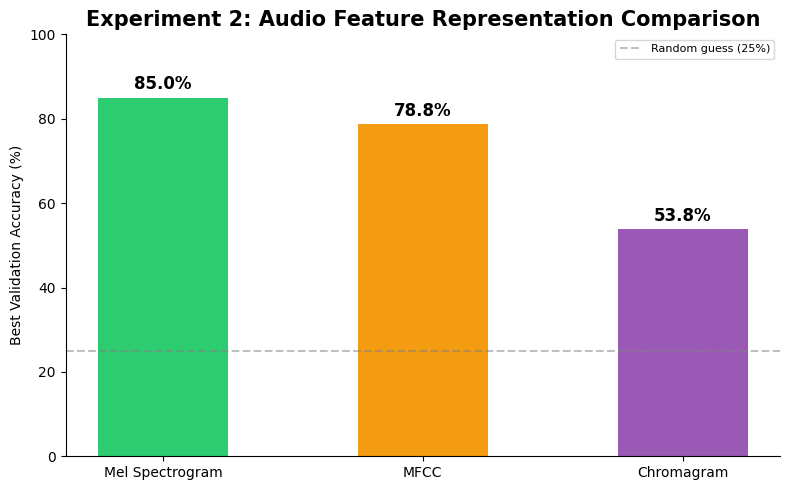

In [ ]:
import matplotlib.pyplot as plt

feature_names = ['Mel Spectrogram', 'MFCC', 'Chromagram']
exp1_accs = [85.00, 78.75, 53.75]

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(feature_names, exp1_accs, color=colors, width=0.5)

ax.set_title('Experiment 2: Audio Feature Representation Comparison', fontsize=15, fontweight='bold')
ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_ylim(0, 100)
ax.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random guess (25%)')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, acc in zip(bars, exp1_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 8. K-Fold Cross-Validation


Instead of relying on a single 80/20 split, k-fold cross-validation trains and evaluates the model 5 times, each time using a different 20% as the validation set. This gives us a more reliable accuracy estimate and a standard deviation to show how consistent the model is.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torchvision import models, datasets
import torch
import torch.nn as nn
import copy
import time
import numpy as np

# Load dataset
DATA_DIR = '/content/drive/MyDrive/DS340_Final_Project/training_images_30s'
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
labels = [label for _, label in full_dataset.samples]

# 5-Fold setup
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
fold_accuracies = []

print(f"Starting {K}-Fold Cross-Validation with ResNet-18...")
print(f"{'='*50}")
total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n--- Fold {fold+1}/{K} ---")

    # Create datasets for this fold
    fold_train = TrainSubset(full_dataset, train_idx, train_transform)
    fold_val = Subset(full_dataset, val_idx)
    fold_train_loader = DataLoader(fold_train, batch_size=32, shuffle=True)
    fold_val_loader = DataLoader(fold_val, batch_size=32, shuffle=False)

    # Fresh ResNet-18 for each fold
    fold_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    fold_model.fc = nn.Linear(fold_model.fc.in_features, len(full_dataset.classes))
    fold_model = fold_model.to(device)

    criterion_fold = nn.CrossEntropyLoss()
    optimizer_fold = torch.optim.Adam(fold_model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler_fold = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold, mode='min', factor=0.5, patience=3
    )

    # Training loop
    best_fold_acc = 0.0
    best_fold_loss = float('inf')
    best_fold_wts = copy.deepcopy(fold_model.state_dict())
    no_improve = 0

    for epoch in range(25):
        for phase in ['train', 'val']:
            if phase == 'train':
                fold_model.train()
                dl = fold_train_loader
                ds_size = len(fold_train)
            else:
                fold_model.eval()
                dl = fold_val_loader
                ds_size = len(fold_val)

            running_loss = 0.0
            running_corrects = 0

            for inputs, lbs in dl:
                inputs = inputs.to(device)
                lbs = lbs.to(device)
                optimizer_fold.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = fold_model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion_fold(outputs, lbs)
                    if phase == 'train':
                        loss.backward()
                        optimizer_fold.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == lbs.data)

            epoch_loss = running_loss / ds_size
            epoch_acc = running_corrects.double() / ds_size

            if phase == 'val':
                scheduler_fold.step(epoch_loss)
                if epoch_loss < best_fold_loss:
                    best_fold_loss = epoch_loss
                    best_fold_acc = epoch_acc.item()
                    best_fold_wts = copy.deepcopy(fold_model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1

        if no_improve >= 5:
            break

    fold_accuracies.append(best_fold_acc)
    print(f"  Fold {fold+1} Best Accuracy: {best_fold_acc:.4f}")

# Summary
total_time = time.time() - total_start
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\n{'='*50}")
print(f"{K}-Fold Cross-Validation Complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")
print(f"{'='*50}")
print(f"  Fold Accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")
print(f"  Mean Accuracy:   {mean_acc:.4f} ± {std_acc:.4f}")
print(f"{'='*50}")

Starting 5-Fold Cross-Validation with ResNet-18...

--- Fold 1/5 ---
  Fold 1 Best Accuracy: 0.8750

--- Fold 2/5 ---
  Fold 2 Best Accuracy: 0.9375

--- Fold 3/5 ---
  Fold 3 Best Accuracy: 0.9625

--- Fold 4/5 ---
  Fold 4 Best Accuracy: 0.9000

--- Fold 5/5 ---
  Fold 5 Best Accuracy: 0.8625

5-Fold Cross-Validation Complete in 6m 19s
  Fold Accuracies: ['0.8750', '0.9375', '0.9625', '0.9000', '0.8625']
  Mean Accuracy:   0.9075 ± 0.0376
